In [2]:
# model evalution and cross validation

In [ ]:
# Model Evaluation metrics for regression and classification

# Model Evaluation for regression
    # 1.Mean squared Error(MSE):
        # -Measures the average squared difference between predicted and actual values.
        # -Sensitive to outliers due to the squaring effect.
        # -Lower values indicate better model performance.
    # 2. Mean Absolute Error(MAE):
        # -Measures the average absolute difference between predicted and actual values.
        # -Less sensitive to outliers compared to MSE.
        # -Lower values indicate better model performance.
        # -provides a more interpretable error metric but less sensitive to outliers.
    # 3. Root Mean Squared Error(RMSE):
        # -Measures the square root of the average squared difference between predicted and actual values.
        # -Provides a unit of measurement similar to the target variable.
        # -Lower values indicate better model performance.
    # 4. R-squared (R2):
        # -Measures the proportion of variance in the target variable explained by the model.
        # -Ranges from 0 to 1, where 1 indicates a perfect fit.
        # -Higher values indicate better model performance.

# Model Evaluation for classification
    # 1. Accuracy:
        # -Measures the proportion of correct predictions out of total predictions.
        # -Ranges from 0 to 1, where 1 indicates a perfect fit.
        # -Higher values indicate better model performance.
        # -useful when the classes are balanced.
    # 2. Precision:
        # -Measures the proportion of true positive predictions out of total positive predictions.
        # -Ranges from 0 to 1, where 1 indicates a perfect fit.
        # -Higher values indicate better model performance.
        # -useful when the classes are imbalanced.
        # -important for applications like fraud detection, where false positives are costly.
    # 3. Recall:
        # -Measures the proportion of true positive predictions out of total actual positive cases.
        # -Ranges from 0 to 1, where 1 indicates a perfect fit.
        # -Higher values indicate better model performance.
        # -useful in cases where missing positive instances is critical
    # 4. F1 Score:
        # -Measures the harmonic mean of precision and recall.
        # -Ranges from 0 to 1, where 1 indicates a perfect fit.
        # -Higher values indicate better model performance.
        # -balances precision and recall, especially useful for imbalanced datasets.
    # 5. ROC AUC:
        # -Measures the area under the receiver operating characteristic curve.
        # -Ranges from 0 to 1, where 1 indicates a perfect fit.
        # -Higher values indicate better model performance.


In [4]:
# Introduction to cross validation

# cross-validation: it is a method of evaluating the performance of a machine learning model by partitioning the data into training and validation sets.

# key cross-validation techniques:
    # 1. k-fold cross-validation:
        # -split the data into k equal parts
        # -train the model on k-1 parts and validate on the remaining part
        # -repeat this process k times, each time using a different part as the validation set
        # the average of the k validation scores is used as the final performance metric
    # 2. stratified k-fold cross-validation:
        # -ensures that each fold has the same distribution of target classes
        # -ensures each fold has a proportional representation of classes in classification problems
    # 3. leave-one-out cross-validation(LOOCV):
        # -train the model on all but one data point and validate on the remaining data point
        # -repeat this process for all data points
        # -computationally expensive
    # 4. time series cross-validation
        # -split the data into training and validation sets based on time
        # -train the model on the training set and validate on the validation set
        # -repeat this process for different time periods
    
# Advantages of cross-validation:
    # 1. provides a more accurate estimate of model performance
    # 2. helps prevent overfitting
    # 3. provides a more reliable estimate of model performance
    # 4/reduces the risk of overfitting


In [6]:
# understanding the confusion matrix

# confusion matrix :  the matrix is a table that is used to describe the performance of a classification model (or "classifier") on a set of test data for which the true values are known.

# Structure of a confusion matrix : 

#                                   Predicted positive    Predicted negative
# Actual positive                   True positive         False negative
# Actual negative                   False positive        True negative

# True positive : 1
# False positive : 0
# False negative : 0
# True negative : 1

# key Metrics Derived
    # 1.True positive rate(TPR) = True positive / (True positive + False negative)
        # -same as recall
    # 2.False positive rate(FPR) = False positive / (False positive + True negative)
        # -proportion of negative incorrectly classified as positives.
    # Specificity = True negative / (True negative + False positive)
        # -proportion of negatives incorrectly classified.
    # 3.Precision = True positive / (True positive + False positive)
    # 4.Recall = True positive / (True positive + False negative)
    # 5.F1 score = 2 * (Precision * Recall) / (Precision + Recall)
    # 6.AUC-ROC = Area Under the Receiver Operating Characteristic Curve


In [7]:
# exercise

In [14]:
# 1.evaluate a model using cross-validation to obtain a more accurate estimate of model performance

from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# initialie the classifier
model = RandomForestClassifier()

# perform K-fold cross-validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')
# n_splits is the number of folds

# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)
print("Average cross-validation score / mean accuracy:", cv_scores.mean())





Cross-validation scores: [1.         0.96666667 0.93333333 0.93333333 0.96666667]
Average cross-validation score / mean accuracy: 0.9600000000000002


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



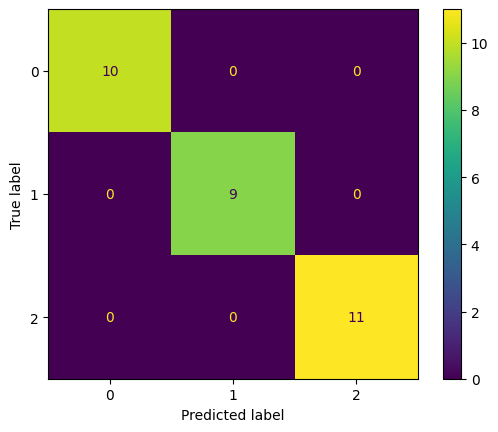

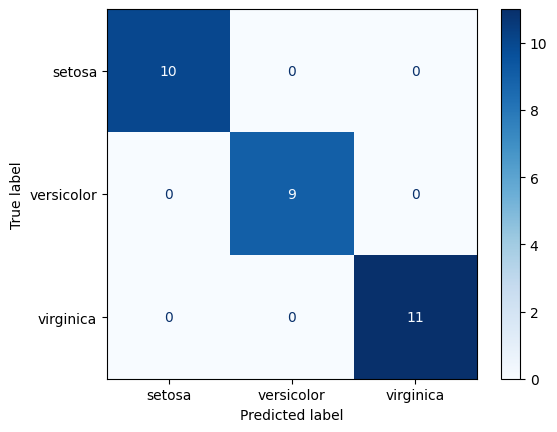

In [24]:
# 2.generate and interpret a confusion matrix for a classification model

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split

# load the dataset
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target

# split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# train the model
model = LogisticRegression()
model.fit(X_train, y_train)

# make predictions on the test set
y_pred = model.predict(X_test)

# generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# display the confusion matrix
ConfusionMatrixDisplay(conf_matrix).plot()
disp=ConfusionMatrixDisplay(conf_matrix, display_labels=iris.target_names)
disp.plot(cmap="Blues")

# print the classification report
print("Classification Report:\n", classification_report(y_test, y_pred))


In [ ]:
# 2.evaluate a model using a hold-out validation set to obtain a more accurate estimate of model performance
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize the model
model = LogisticRegression()

# Train the model on the training set
model.fit(X_train, y_train)

# Evaluate the model on the testing set
score = model.score(X_test, y_test)
print("Testing set score:", score)

# 3. evaluate a model using k-fold cross-validation to obtain a more accurate estimate of model performance
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

# Load the iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Initialize the model
model = LogisticRegression()

# Perform k-fold cross-validation
scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores:", scores)
print("Average cross-validation score:", scores.mean())


Testing set score: 1.0
Cross-validation scores: [0.96666667 1.         0.93333333 0.96666667 1.        ]
Average cross-validation score: 0.9733333333333334


c:\Users\Usha Biratthi\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
